# Preprocessing dan Ekstraksi Fitur
Notebook ini telah dirapikan agar setiap polutan memiliki alur preprocessing dan ekstraksi fiturnya masing-masing.


## CO


In [89]:
import pandas as pd
df = pd.read_csv("CO.csv")
df['date'] = pd.to_datetime(df['date'])

start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])
print(f"Jumlah hari missing (CO): {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing (CO): 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-31'], dtype='datetime64[ns]', freq='D')


In [90]:
df = pd.read_csv("CO.csv")
missing_value = df['CO'].isna().sum()
print(f"Jumlah missing value pada kolom CO: {missing_value}")

Jumlah missing value pada kolom CO: 59


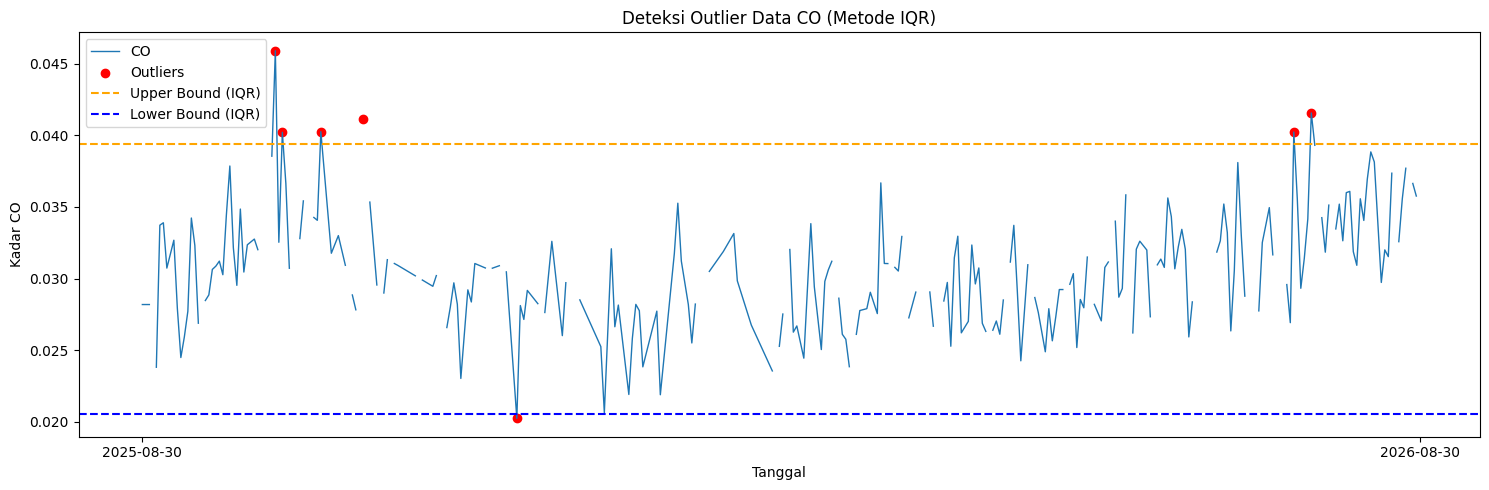

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("CO.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['CO'] = pd.to_numeric(df['CO'], errors='coerce')

Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['CO'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

In [92]:
df['CO_cleaned'] = df['CO'].mask((df['CO'] < lower_bound) | (df['CO'] > upper_bound))
df['CO_filled'] = df['CO_cleaned'].interpolate(method='linear').bfill().ffill()

df_co = pd.DataFrame({"date": df['date'], "CO": df['CO_filled']})
df_co.to_csv("CO_filed.csv", index=False)
print("Data CO berhasil diproses dan disimpan ke CO_filed.csv")

Data CO berhasil diproses dan disimpan ke CO_filed.csv


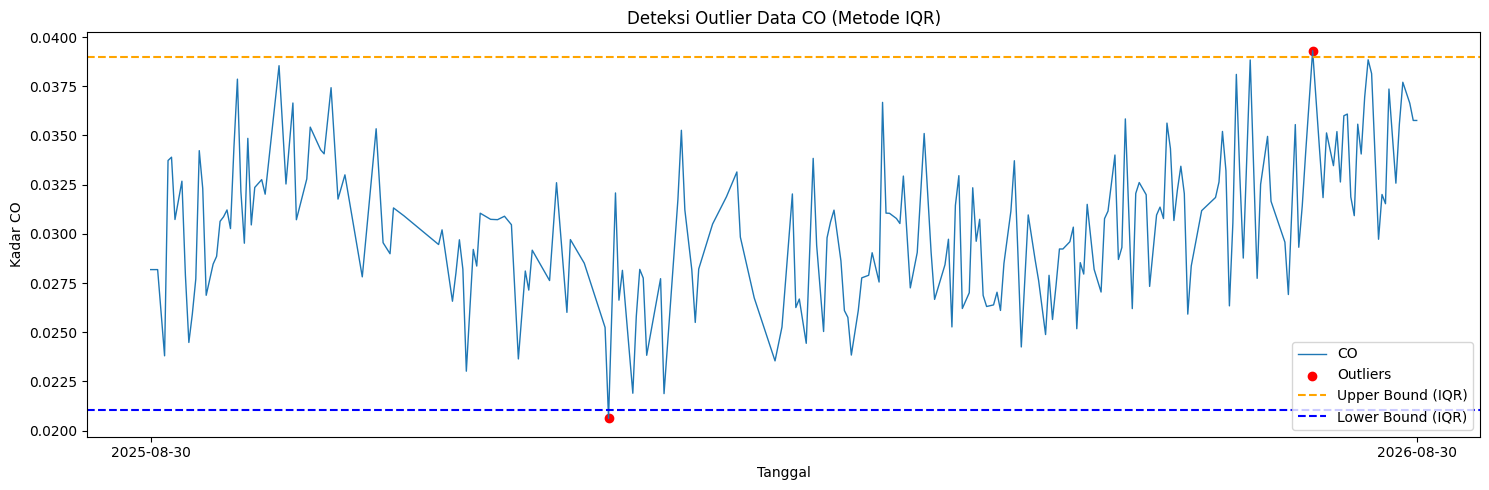

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("CO_filed.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['CO'] = pd.to_numeric(df['CO'], errors='coerce')

Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['CO'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

# karena masih ada outlier lagi maka kita interpolasi lagi 

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("CO_filed.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['CO'] = pd.to_numeric(df['CO'], errors='coerce')

Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['CO_cleaned'] = df['CO'].mask((df['CO'] < lower_bound) | (df['CO'] > upper_bound))
df['CO_filled'] = df['CO_cleaned'].interpolate(method='linear').bfill().ffill()

df_co = pd.DataFrame({"date": df['date'], "CO": df['CO_filled']})
df_co.to_csv("CO_filed_2.csv", index=False)
print("Data CO berhasil diproses dan disimpan ke CO_filed_2.csv")

Data CO berhasil diproses dan disimpan ke CO_filed_2.csv


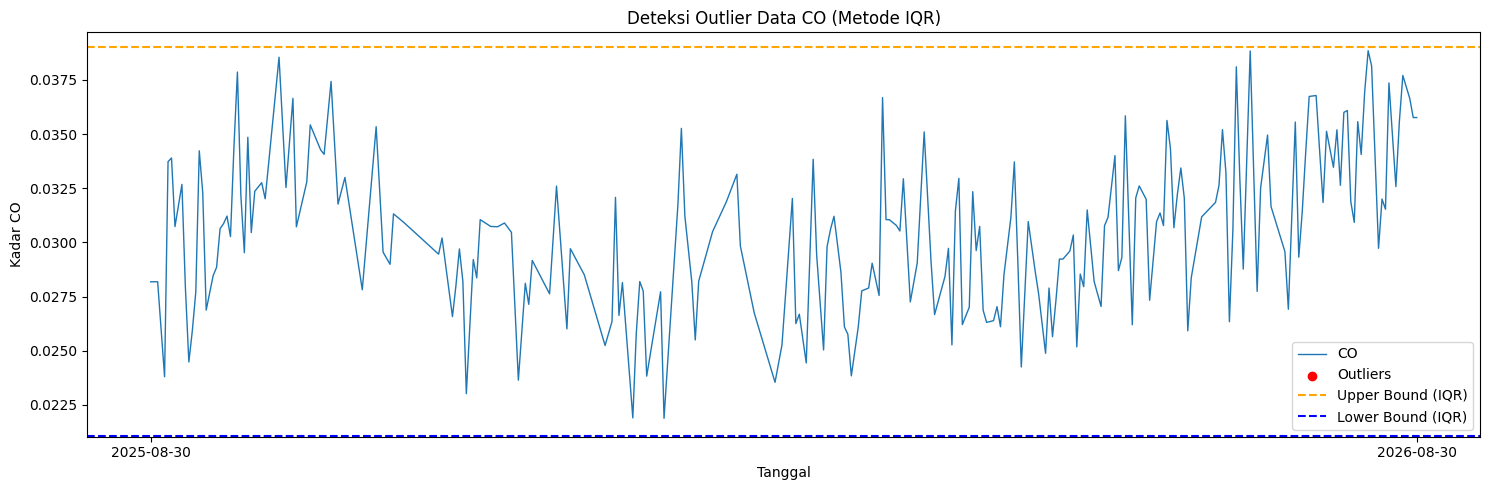

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("CO_filed_2.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['CO'] = pd.to_numeric(df['CO'], errors='coerce')

Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['CO'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

In [113]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

df = pd.read_csv('CO_filed_2.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
target_pollutant = 'CO'
fs = 1
signal_1d = df[target_pollutant].astype(float).values

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

extracted_features_final.to_csv(f'{target_pollutant}_Baron_TSFEL.csv', index=False)

print(f"Berhasil mengekstrak {len(FEATURE_LIST)} fitur untuk {target_pollutant}.")
print(f"Hasil fitur disimpan ke {target_pollutant}_Baron_TSFEL.csv (Format Feature - Value)")


Berhasil mengekstrak 68 fitur untuk CO.
Hasil fitur disimpan ke CO_Baron_TSFEL.csv (Format Feature - Value)


## SO2


In [97]:
import pandas as pd
df = pd.read_csv("SO2.csv")
df['date'] = pd.to_datetime(df['date'])

start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])
print(f"Jumlah hari missing (SO2): {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing (SO2): 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-31'], dtype='datetime64[ns]', freq='D')


In [98]:
df = pd.read_csv("SO2.csv")
missing_value = df['SO2'].isna().sum()
print(f"Jumlah missing value pada kolom SO2: {missing_value}")

Jumlah missing value pada kolom SO2: 41


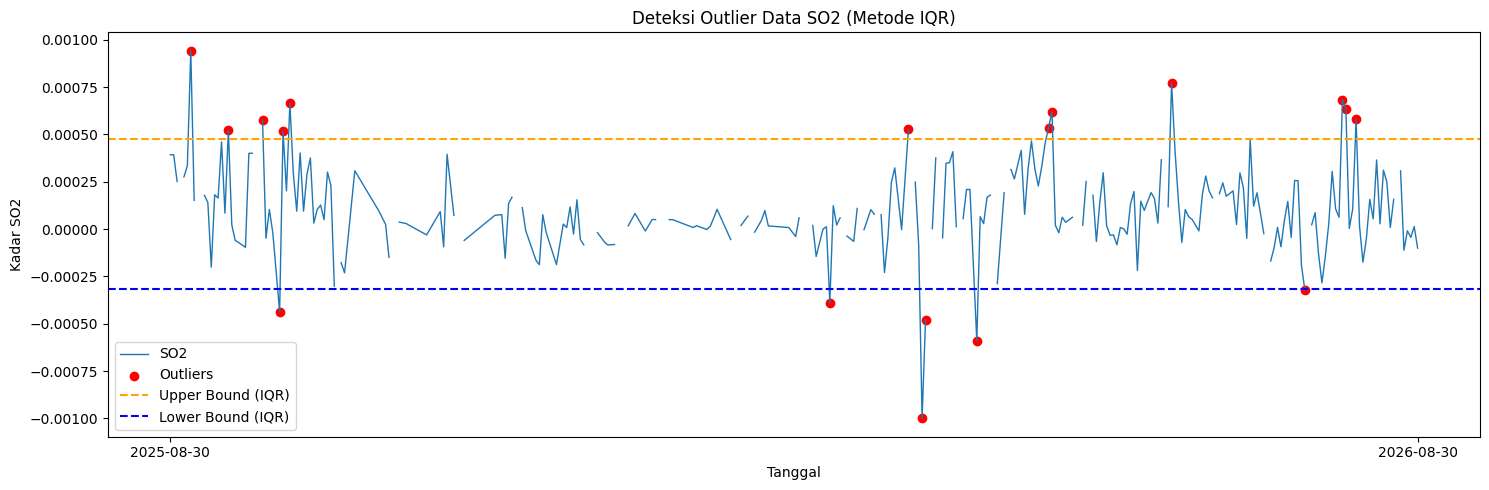

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SO2.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['SO2'] = pd.to_numeric(df['SO2'], errors='coerce')

Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

In [100]:
df['SO2_cleaned'] = df['SO2'].mask((df['SO2'] < lower_bound) | (df['SO2'] > upper_bound))
df['SO2_filled'] = df['SO2_cleaned'].interpolate(method='linear').bfill().ffill()

df_so2 = pd.DataFrame({"date": df['date'], "SO2": df['SO2_filled']})
df_so2.to_csv("SO2_filed.csv", index=False)
print("Data SO2 berhasil diproses dan disimpan ke SO2_filed.csv")

Data SO2 berhasil diproses dan disimpan ke SO2_filed.csv


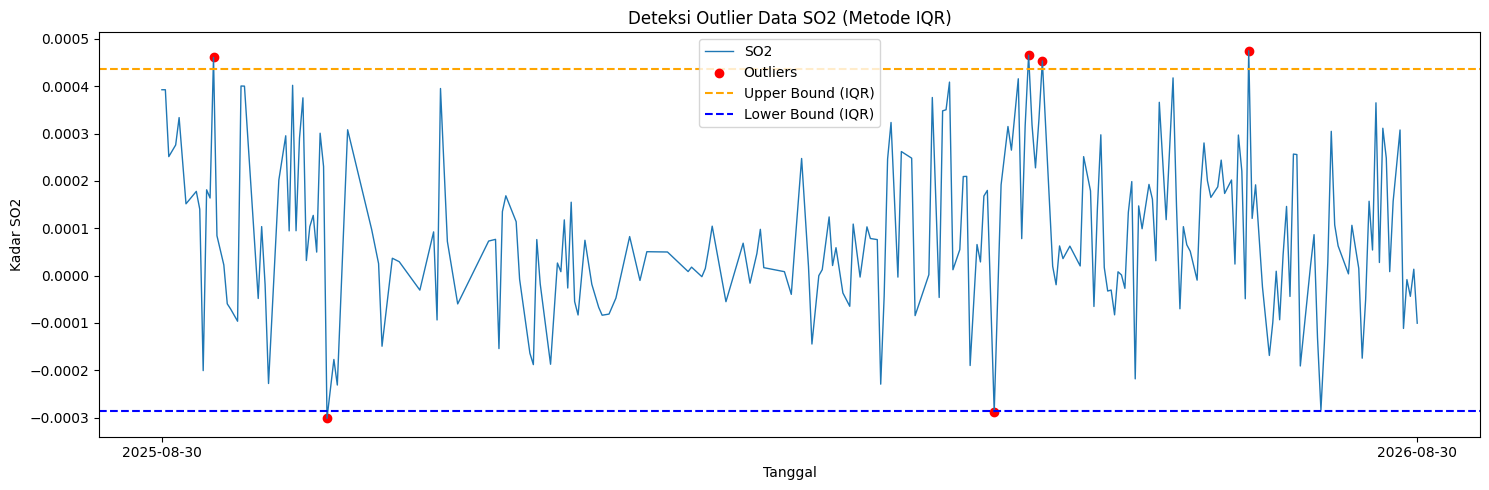

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SO2_filed.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['SO2'] = pd.to_numeric(df['SO2'], errors='coerce')

Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

# karena masih ada outlier

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SO2_filed.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['SO2'] = pd.to_numeric(df['SO2'], errors='coerce')

Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['SO2_cleaned'] = df['SO2'].mask((df['SO2'] < lower_bound) | (df['SO2'] > upper_bound))
df['SO2_filled'] = df['SO2_cleaned'].interpolate(method='linear').bfill().ffill()

df_so2 = pd.DataFrame({"date": df['date'], "SO2": df['SO2_filled']})
df_so2.to_csv("SO2_filed_2.csv", index=False)
print("Data SO2 berhasil diproses dan disimpan ke SO2_filed_2.csv")

Data SO2 berhasil diproses dan disimpan ke SO2_filed_2.csv


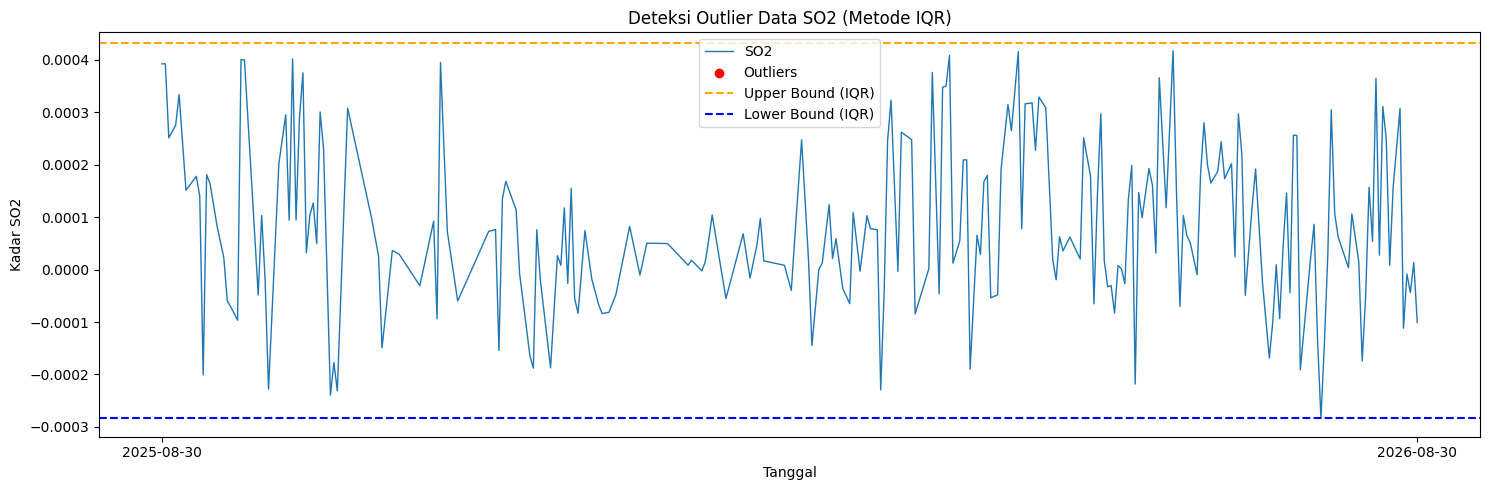

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SO2_filed_2.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['SO2'] = pd.to_numeric(df['SO2'], errors='coerce')

Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

In [112]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

df = pd.read_csv('SO2_filed_2.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
target_pollutant = 'SO2'
fs = 1
signal_1d = df[target_pollutant].astype(float).values

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

extracted_features_final.to_csv(f'{target_pollutant}_Baron_TSFEL.csv', index=False)

print(f"Berhasil mengekstrak {len(FEATURE_LIST)} fitur untuk {target_pollutant}.")
print(f"Hasil fitur disimpan ke {target_pollutant}_Baron_TSFEL.csv (Format Feature - Value)")


Berhasil mengekstrak 68 fitur untuk SO2.
Hasil fitur disimpan ke SO2_Baron_TSFEL.csv (Format Feature - Value)


## NO2


In [105]:
import pandas as pd
df = pd.read_csv("NO2.csv")
df['date'] = pd.to_datetime(df['date'])

start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

missing_dates = full_range.difference(df['date'])
print(f"Jumlah hari missing (NO2): {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing (NO2): 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-31'], dtype='datetime64[ns]', freq='D')


In [106]:
df = pd.read_csv("NO2.csv")
missing_value = df['NO2'].isna().sum()
print(f"Jumlah missing value pada kolom NO2: {missing_value}")

Jumlah missing value pada kolom NO2: 62


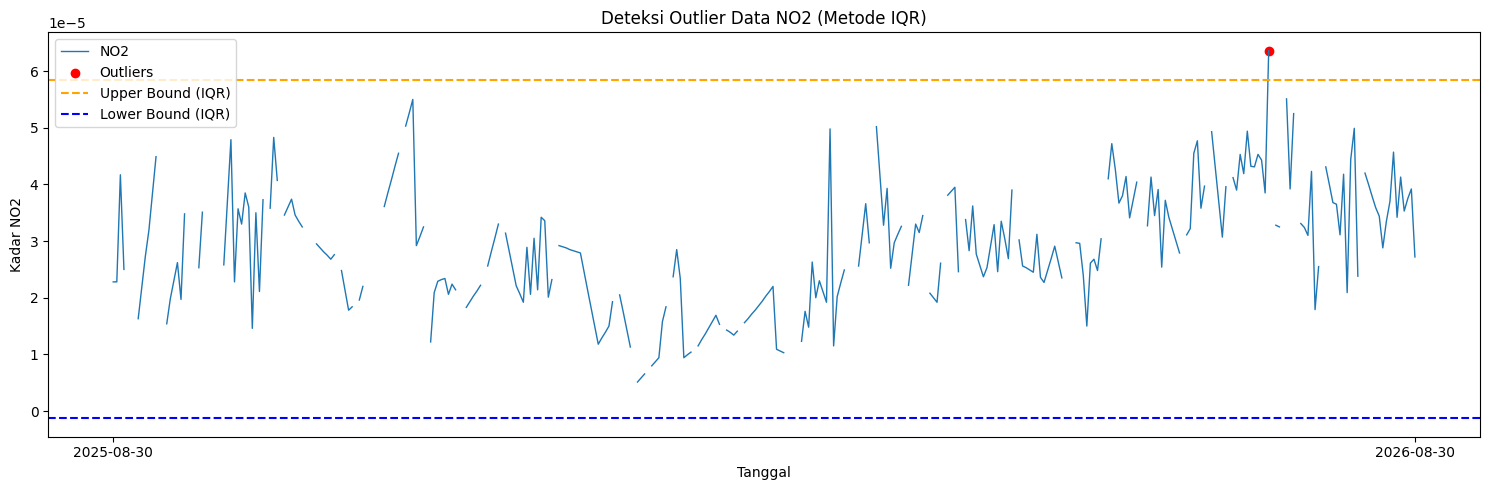

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['NO2'] = pd.to_numeric(df['NO2'], errors='coerce')

Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

In [108]:
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear').bfill().ffill()

df_no2 = pd.DataFrame({"date": df['date'], "NO2": df['NO2_filled']})
df_no2.to_csv("NO2_filed.csv", index=False)
print("Data NO2 berhasil diproses dan disimpan ke NO2_filed.csv")

Data NO2 berhasil diproses dan disimpan ke NO2_filed.csv


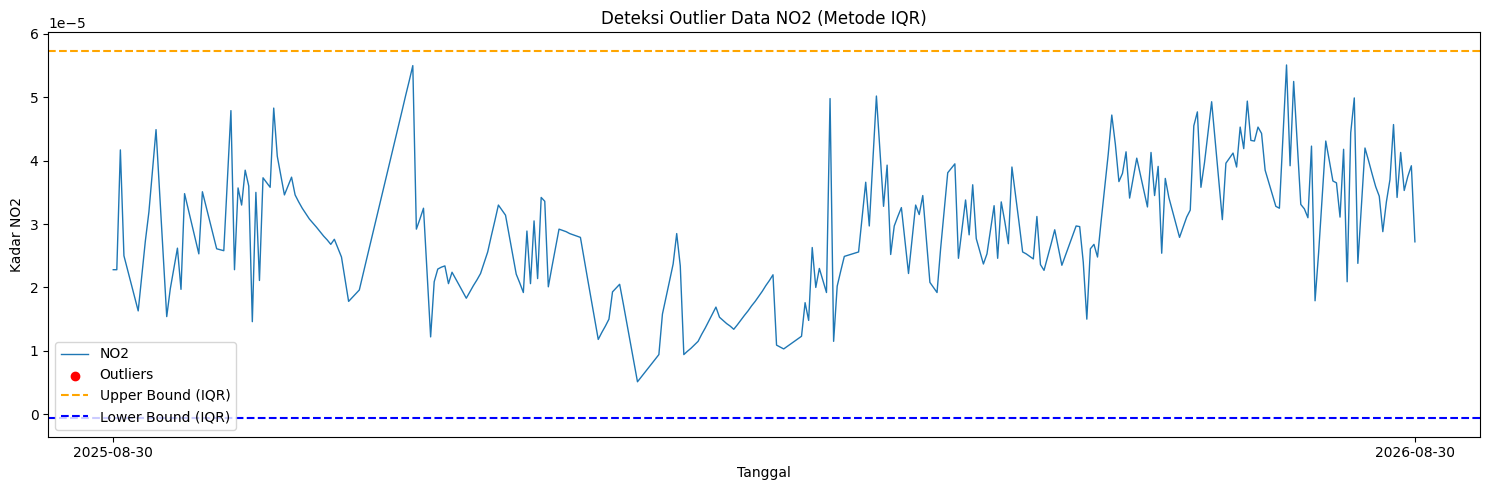

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2_filed.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['NO2'] = pd.to_numeric(df['NO2'], errors='coerce')

Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'], color='red', marker='o', label="Outliers")
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(ticks=[df['date'].iloc[0], df['date'].iloc[-1]], labels=[df['date'].iloc[0].strftime('%Y-%m-%d'), df['date'].iloc[-1].strftime('%Y-%m-%d')])
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

df = pd.read_csv('NO2_filed.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
target_pollutant = 'NO2'
fs = 1
signal_1d = df[target_pollutant].astype(float).values

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

extracted_features_final.to_csv(f'{target_pollutant}_Baron_TSFEL.csv', index=False)

print(f"Berhasil mengekstrak {len(FEATURE_LIST)} fitur untuk {target_pollutant}.")
print(f"Hasil fitur disimpan ke {target_pollutant}_Baron_TSFEL.csv (Format Feature - Value)")


Berhasil mengekstrak 68 fitur untuk NO2.
Hasil fitur disimpan ke NO2_Baron_TSFEL.csv (Format Feature - Value)
